In [75]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
import yfinance as yf

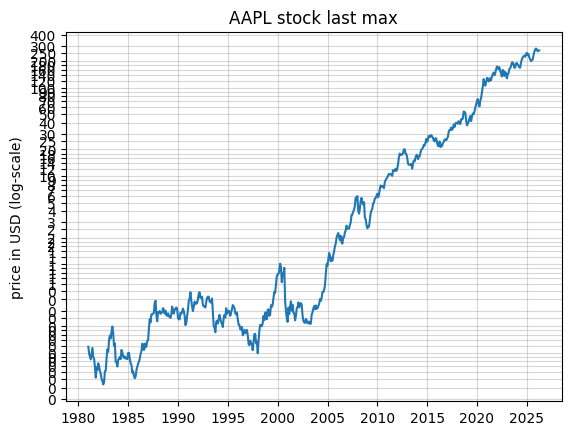

In [73]:
# long stock history of closing price

stock_ticker = "AAPL"
stock = yf.Ticker(stock_ticker)
per = "max"

history_length = stock.history(period=per)

end_of_month_closing = history_length["Close"].resample("ME").last()
closing_list = end_of_month_closing.to_list()

dates = end_of_month_closing.index

plt.semilogy(dates, closing_list)
ax = plt.gca()
# Formatter für Haupt- und Zwischenlinien setzen
ax.yaxis.set_major_formatter(ticker.ScalarFormatter())
ax.yaxis.set_minor_formatter(ticker.ScalarFormatter())

# Wissenschaftliche Notation (1e2) für beide abschalten
ax.yaxis.get_major_formatter().set_scientific(False)
ax.yaxis.get_minor_formatter().set_scientific(False)

# Optional: Setzt Markierungen bei 1, 2, 5 (verhindert Überlappung)
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1, 2, 3, 4, 5, 6, 7, 8, 9, 12, 14, 16, 18, 25)))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=(1, 2, 5, 10, 100)))

plt.grid(True, which="both", ls="-", alpha=0.5) # Gitter für beide Skalierungen
plt.ylabel("price in USD (log-scale)")

plt.title(stock_ticker +  " stock last " + per)
plt.show()


In [99]:
# Daten abrufen
stock_ticker = "AAPL"
stock = yf.Ticker(stock_ticker)
per = "max"

history_length = stock.history(period=per)

# Resampling
end_of_month_closing = history_length["Close"].resample("ME").last()
closing_list = end_of_month_closing.to_list()
dates = end_of_month_closing.index

plt.figure(figsize=(10, 6))
plt.semilogy(dates, closing_list)

ax = plt.gca()

# X-Achse Abstände
ax.xaxis.set_major_locator(mdates.YearLocator(base=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# Y-Achse Formatter
# %g zeigt 7.5 als 7.5 an, ohne zu runden
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
ax.yaxis.set_minor_formatter(ticker.FormatStrFormatter('%g'))

# Ticker-Werte setzen
ax.yaxis.set_major_locator(ticker.LogLocator(base=10, subs=(1,))) 
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10, subs=(1, 1.5, 2, 3, 5, 7.5)))

# Schriftgröße verkleinern, damit alle Zahlen Platz haben
ax.tick_params(axis='y', which='both', labelsize=9)

# X-Achse: Bei "max" (40+ Jahre) ist base=1 zu eng, base=2 oder 4 ist besser
ax.xaxis.set_major_locator(mdates.YearLocator(base=4))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.grid(True, which="both", ls="-", alpha=0.4)

KeyboardInterrupt: 